In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

TESTE T: 

UMA EMPRESA QUER SABER SE UMA NOVA LANDING PAGE LEVA A UMA TAXA DE CONVERSÃO MAIOR QUE A ANTIGA:

 1. Hipótese Nula(H0): A taxa de conversão da nova pagina de destino é igual ou menor do que a da página antiga.
 2. Hipótese Alternativa(H1): A taxa de conversão da nova página de destino é maior do que a da página antiga.

In [2]:
# Taxas de conversão observadas para a nova e antiga LP
taxa_conversao_nova = np.array([0.08, 0.09, 0.07, 0.1, 0.11, 0.09, 0.08, 0.1, 0.12, 0.1,
                                0.09, 0.08, 0.09, 0.11, 0.1, 0.08, 0.09, 0.08, 0.1, 0.11, 0.07,0.07,0.07,0.08])
taxa_conversao_antiga = np.array([0.07, 0.09, 0.08, 0.09, 0.10, 0.07, 0.08, 0.09, 0.08, 0.07,
                                  0.09, 0.08, 0.10, 0.09, 0.07, 0.09, 0.06, 0.09, 0.07, 0.06, 0.06,0.06,0.06,0.07])



In [3]:
# Realizando o teste de hipótese

# t_statistic, p_valor -> Atribui os resultados do teste t a duas variáveis
# stats.ttest_ind -> Função que realiza o teste t para duas amostras independentes
t_statistic, p_valor = stats.ttest_ind(taxa_conversao_nova, taxa_conversao_antiga)

# imprimindo os resultados da variável criada t_statistic e p_valor do teste
print("Estatística de teste (t-statistic):", t_statistic)
print("Valor-p (p-value):", p_valor)

# Comparando o p-valor com um nível de significância comum(0.05) criando uma regra para trazer a resposta ideal
nivel_significancia = 0.05
if p_valor < nivel_significancia:
    print("Rejeitamos a hipótese nula. Há evidências suficientes para sugerir que as taxas de conversão são diferentes.")
else:
    print("Não rejeitamos a hipótese nula. Não há evidências suficientes para sugerir que as taxas de conversão são diferentes.")



Estatística de teste (t-statistic): 3.0270374865616985
Valor-p (p-value): 0.00403730766024186
Rejeitamos a hipótese nula. Há evidências suficientes para sugerir que as taxas de conversão são diferentes.


Gráfico que compara a curva de densidade da amostra do site antigo e do site novo:

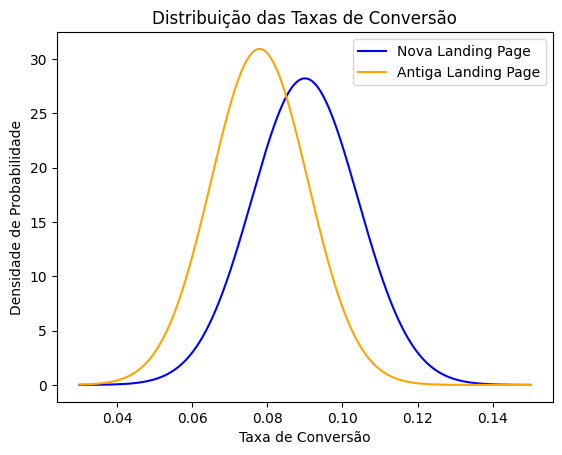

In [5]:
# Calculando média e desvio padrão das taxas de conversão
media_nova = np.mean(taxa_conversao_nova) 
desvio_padrao_nova = np.std(taxa_conversao_nova)
media_antiga = np.mean(taxa_conversao_antiga)
desvio_padrao_antiga = np.std(taxa_conversao_antiga)

# Abaixo criamos um intervalo de valores para plotagem
x = np.linspace(0.03, 0.15, 1000)

# Plotando a densidade de probabilidade das taxas de conversão
plt.plot(x, norm.pdf(x, media_nova, desvio_padrao_nova), label='Nova Landing Page', color='blue')
plt.plot(x, norm.pdf(x, media_antiga, desvio_padrao_antiga), label='Antiga Landing Page', color='orange')
plt.xlabel('Taxa de Conversão')
plt.ylabel('Densidade de Probabilidade')
plt.title('Distribuição das Taxas de Conversão')
plt.legend()
plt.show()

Da pra notar que na LP antifa a maior probabilidade de valores se encontrava entre 6% e 8% enquanto que na nova LP entre 8% e 10%

Reproduzindo o gráfico do nosso test t visualizando a área crítica

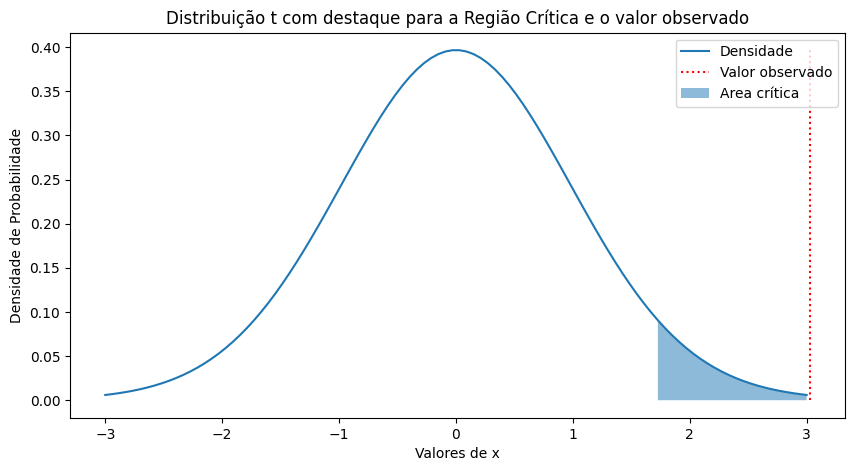

In [6]:
# Configurações padrão do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Parâmetros da densidade sob H0
mu = 0 # É a média da distribuição t sob a hipótese nula, no caso da distribuição t, a média é sempre 0
variance = 1 # É a variância da distribuição t sob a hipótese nula, para a distribuição t, a média é sempre 1
sigma = variance**.5 # É o desvio padrão da distribuição t sob a hipótese nula. Como a variancia é 1, o desvio padrão é a raiz quadrada da variância, ou seja, 0.5.

# Valores de X e Y para plotar a densidade do nosso gráfico
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
y = stats.t.pdf(x, len(taxa_conversao_nova) + len(taxa_conversao_antiga) - 2) # Calcula a densidade da distribuição t para os valores de x

# Essas linhas de código estão calculando os limites da região crítica do test t
low = stats.t.ppf(.95, len(taxa_conversao_nova) + len(taxa_conversao_antiga) - 2) # Calcula o valor crítico inferior para a distribuição t
#Len(taxa_conversao_antiga) - 2 -> Calcula o percentil 95 da distribuição t.

high = np.inf # Define o limite superior da região crítica como infinito

# Gráfico da densidade
ax.plot(x, y, label="Densidade")

# Marcação do valor observado da estatística do teste
ax.vlines(x=[t_statistic], ymin=0, ymax=y.max(), colors='r', linestyles='dotted', label='Valor observado')

# Preenchendo a área crítica
plt.fill_between(x, y, where=(low < x) & (x < high), alpha=.5, label='Area crítica') # Pinta a área crítica do gráfico, que é a região onde rejeitamos a hipótese nula.

# Plotagem padrão do gráfico
plt.legend()
plt.xlabel('Valores de x')
plt.ylabel('Densidade de Probabilidade')
plt.title('Distribuição t com destaque para a Região Crítica e o valor observado')
plt.show()


 